# Análisis de Datos Exploratorio (EDA)



## Descripción del dataset



In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plotnine import *
from src.get_data import get_data

# get the data from kagglehub
df = get_data()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

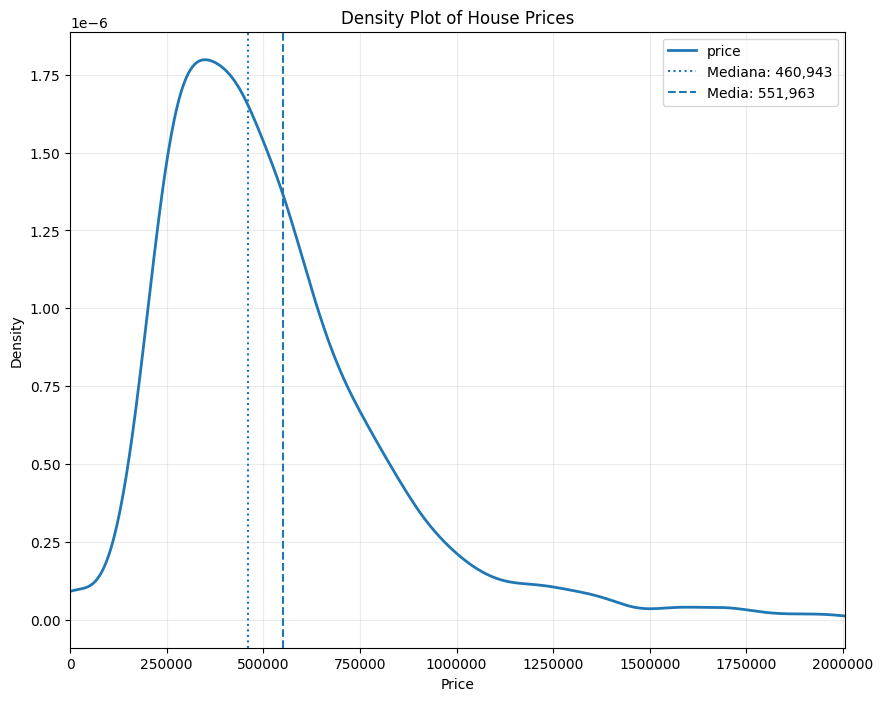

In [8]:
priceData = df['price'].dropna()
priceLimit = priceData.quantile(0.99)

priceDataForPlot = priceData[
    (priceData >= 0) &
    (priceData <= priceLimit)
]

plt.figure(figsize=(10, 8))

priceDataForPlot.plot(
    kind='density',
    linewidth=2
)

plt.axvline(
    priceData.median(),
    linestyle=':',
    label=f"Mediana: {priceData.median():,.0f}"
)

plt.axvline(
    priceData.mean(),
    linestyle='--',
    label=f"Media: {priceData.mean():,.0f}"
)

plt.title('Density Plot of House Prices')
plt.xlabel('Price')
plt.ylabel('Density')
plt.xlim(0, priceLimit)
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.grid(alpha=0.25)

plt.show()

### Gráfico de densidad del precio
**Descripción del gráfico:**

Para este gráfico se analizó la distribución de price de las viviendas del dataset. El gráfico de densidad permite observar en qué rangos de precio se concentra la mayor cantidad de viviendas y cómo se distribuyen los valores. Debido a la presencia de precios extremadamente altos, se acotó el rango mostrado para facilitar la visualización de la distribución principal, sin eliminar estos datos del dataset.


**Hallazgos Principales:**
- La mayor concentración de viviendas se encuentra aproximadamente entre los 250 000 y 600 000, con el punto de mayor densidad cercano a los 350 000.
- La distribución presenta una asimetría hacia la derecha, ya que la densidad disminuye progresivamente conforme aumentan los precios y se forma una cola hacia valores altos.
- La media del precio, aproximadamente 551 963, es mayor que la mediana de 460 943, lo cual indica que las viviendas con precios elevados están aumentando el valor promedio.


**Conclusión:** La variable price presenta una distribución asimétrica hacia la derecha, con una mayor concentración de viviendas en los rangos de precio bajos y medios y una menor cantidad de viviendas con precios elevados. La diferencia entre la media y la mediana confirma la influencia de estos valores altos.



Valores faltantes:
sqft_living    0
price          0
dtype: int64
Correlación de Pearson: 0.43


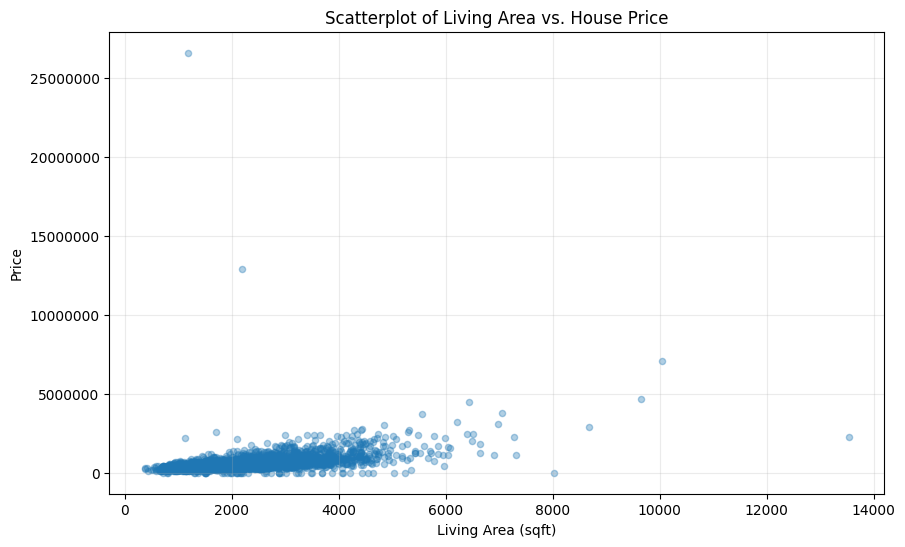

In [12]:
scatterData = df[['sqft_living', 'price']].dropna()

print("Valores faltantes:")
print(df[['sqft_living', 'price']].isna().sum())

priceAreaCorrelation = scatterData['sqft_living'].corr(scatterData['price'])
print(f"Correlación de Pearson: {priceAreaCorrelation:.2f}")

plt.figure(figsize=(10, 6))

plt.scatter(
    scatterData['sqft_living'],
    scatterData['price'],
    alpha=0.35,
    s=20
)

plt.title('Scatterplot of Living Area vs. House Price')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(alpha=0.25)
plt.show()


### Scatterplot: área habitable vs. precio

**Descripción del Gráfico:**
Para este gráfico se comparó el área habitable de las viviendas (sqft_living) con su precio (price) con el objetivo de observar si existe una relación entre ambas variables.


**Hallazgos Principales:**
- Se observa una tendencia positiva entre sqft_living y price, ya que generalmente las viviendas con mayor área habitable presentan precios más altos
- La mayor parte de las viviendas se concentra aproximadamente entre 500 y 5 000 pies cuadrados, con precios inferiores a 2 500 000.
- La dispersión de los puntos aumenta conforme crece el área habitable
- Si existen puntos alejados del comportamiento general que podrían influir en la correlación.

**Conclusión:**
Se observa que sqft_living mantiene una relación positiva con price, por lo que el área habitable podría considerarse un posible factor de interés para explicar el precio de una vivienda. Sin embargo, la dispersión de los puntos muestra que el área habitable por sí sola no determina el precio, por lo que sería necesario considerar otros factores. Además, los valores extremos deben tomarse en cuenta porque podrían afectar análisis estadísticos posteriores.

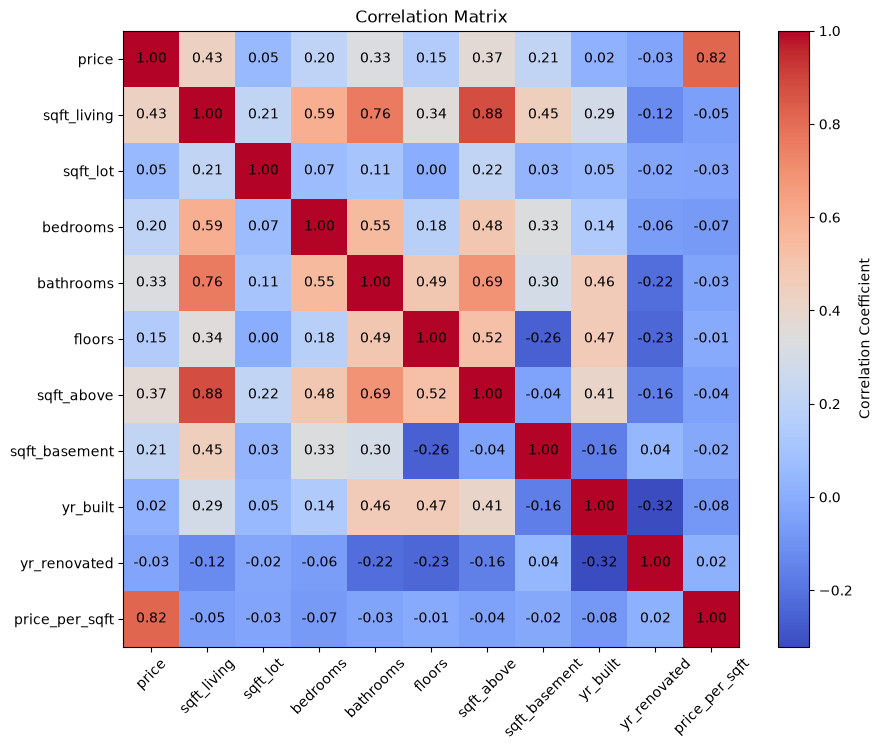

In [5]:
# Correlation matrix
corr_cols = ['price', 'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'floors', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'price_per_sqft']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')
plt.title('Correlation Matrix')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.show()

### Matriz de Correlación

**Descripción del gráfico:**
En base a las variables númericas del dataset correlacionables, se obtuvo el coeficiente de correlación de Pearson. Cada celda de la matriz representa la de relación entre las variables fila-columna, entre valores de -1 y 1.

**Hallazgos principales:**
- la correlación más alta encontrada es entre sqft_living y sqft_above siendo de 0.88, aunque no es un hallazgo que sorprenda ya que sqft_above es un subconjunto de sqft_living.
- Sorprendentemente, la correlación entre el precio de los hogares (price) y la cantidad de habitaciones que poseen (bedrooms) es relativamente baja, siendo de 0.20, mostrando que el precio de una vivienda no está justificado por la cantidad de habitaciones.
- Otra correlación que no acaba justificando el precio de un hogar es el de sqft_living y price_per_sqft, ya que su correlación es casi nula (-0,05). Esto demuestra que el precio por metro cuadrado de una casa no necesariamente se debe al tamaño de esta.
**Conclusión:**
Debería evitarse el uso de sqft_living y sqft_above ya que la información que aportan es poco relevante. Además, características como la cantidad de habitaciones o el tamaño de la vivienda poseen baja correlación con el precio, lo que sugiere que hay otras variables que tengan mayor influencia en ello, como la ubicación.

### Heatmaps

### Precio promedio por ciudad y condición de vivienda

**Descripción del gráfico:** En el gráfico se pueden observar todas las ciudades del dataset (*city*) en el eje $y$ y la condición de la vivienda (*condition*) en el eje $x$, siendo 1 peor y 5 mejor. Cada celda contiene el precio (*price*) promedio de las viviendas de la ciudad y condición a las que pertenecen y el gradiente del color correspondiente a dicho promedio.

**Hallazgos principales:** 
- Se observa que las ciudades 'Clyde Hill', 'Mercer Island', 'Yarrow Point' y 'Medina' son las 4 ciudades con un mayor precio promedio, ademas de que la mayoría de las viviendas se encuentran en buena condición, entre 3 y 4.
- Se ve que hay muchas ciudades sin viviendas con un 1, el peor estado, de condición. Por otro lado, la gran mayoría de viviendas se encuentran con condición 3 o 4.
- Se puede ver una tendencia de que el precio no siempre aumenta con la condición. En ciudades como Seattle hay un claro aumento del precio por condición o en Tukwila casas en condición 1 promedian $7,800 y en condición 3 $242,317, pero en la gran mayoría no se puede ver una correlación clara.
- 



             city  condition         price
0          Algona          3  2.016100e+05
1          Algona          4  2.300000e+05
2          Auburn          2  3.250000e+05
3          Auburn          3  3.263965e+05
4          Auburn          4  2.568732e+05
..            ...        ...           ...
129   Woodinville          3  6.294968e+05
130   Woodinville          4  5.895204e+05
131   Woodinville          5  5.268000e+05
132  Yarrow Point          3  1.901000e+06
133  Yarrow Point          4  9.594500e+05

[134 rows x 3 columns]


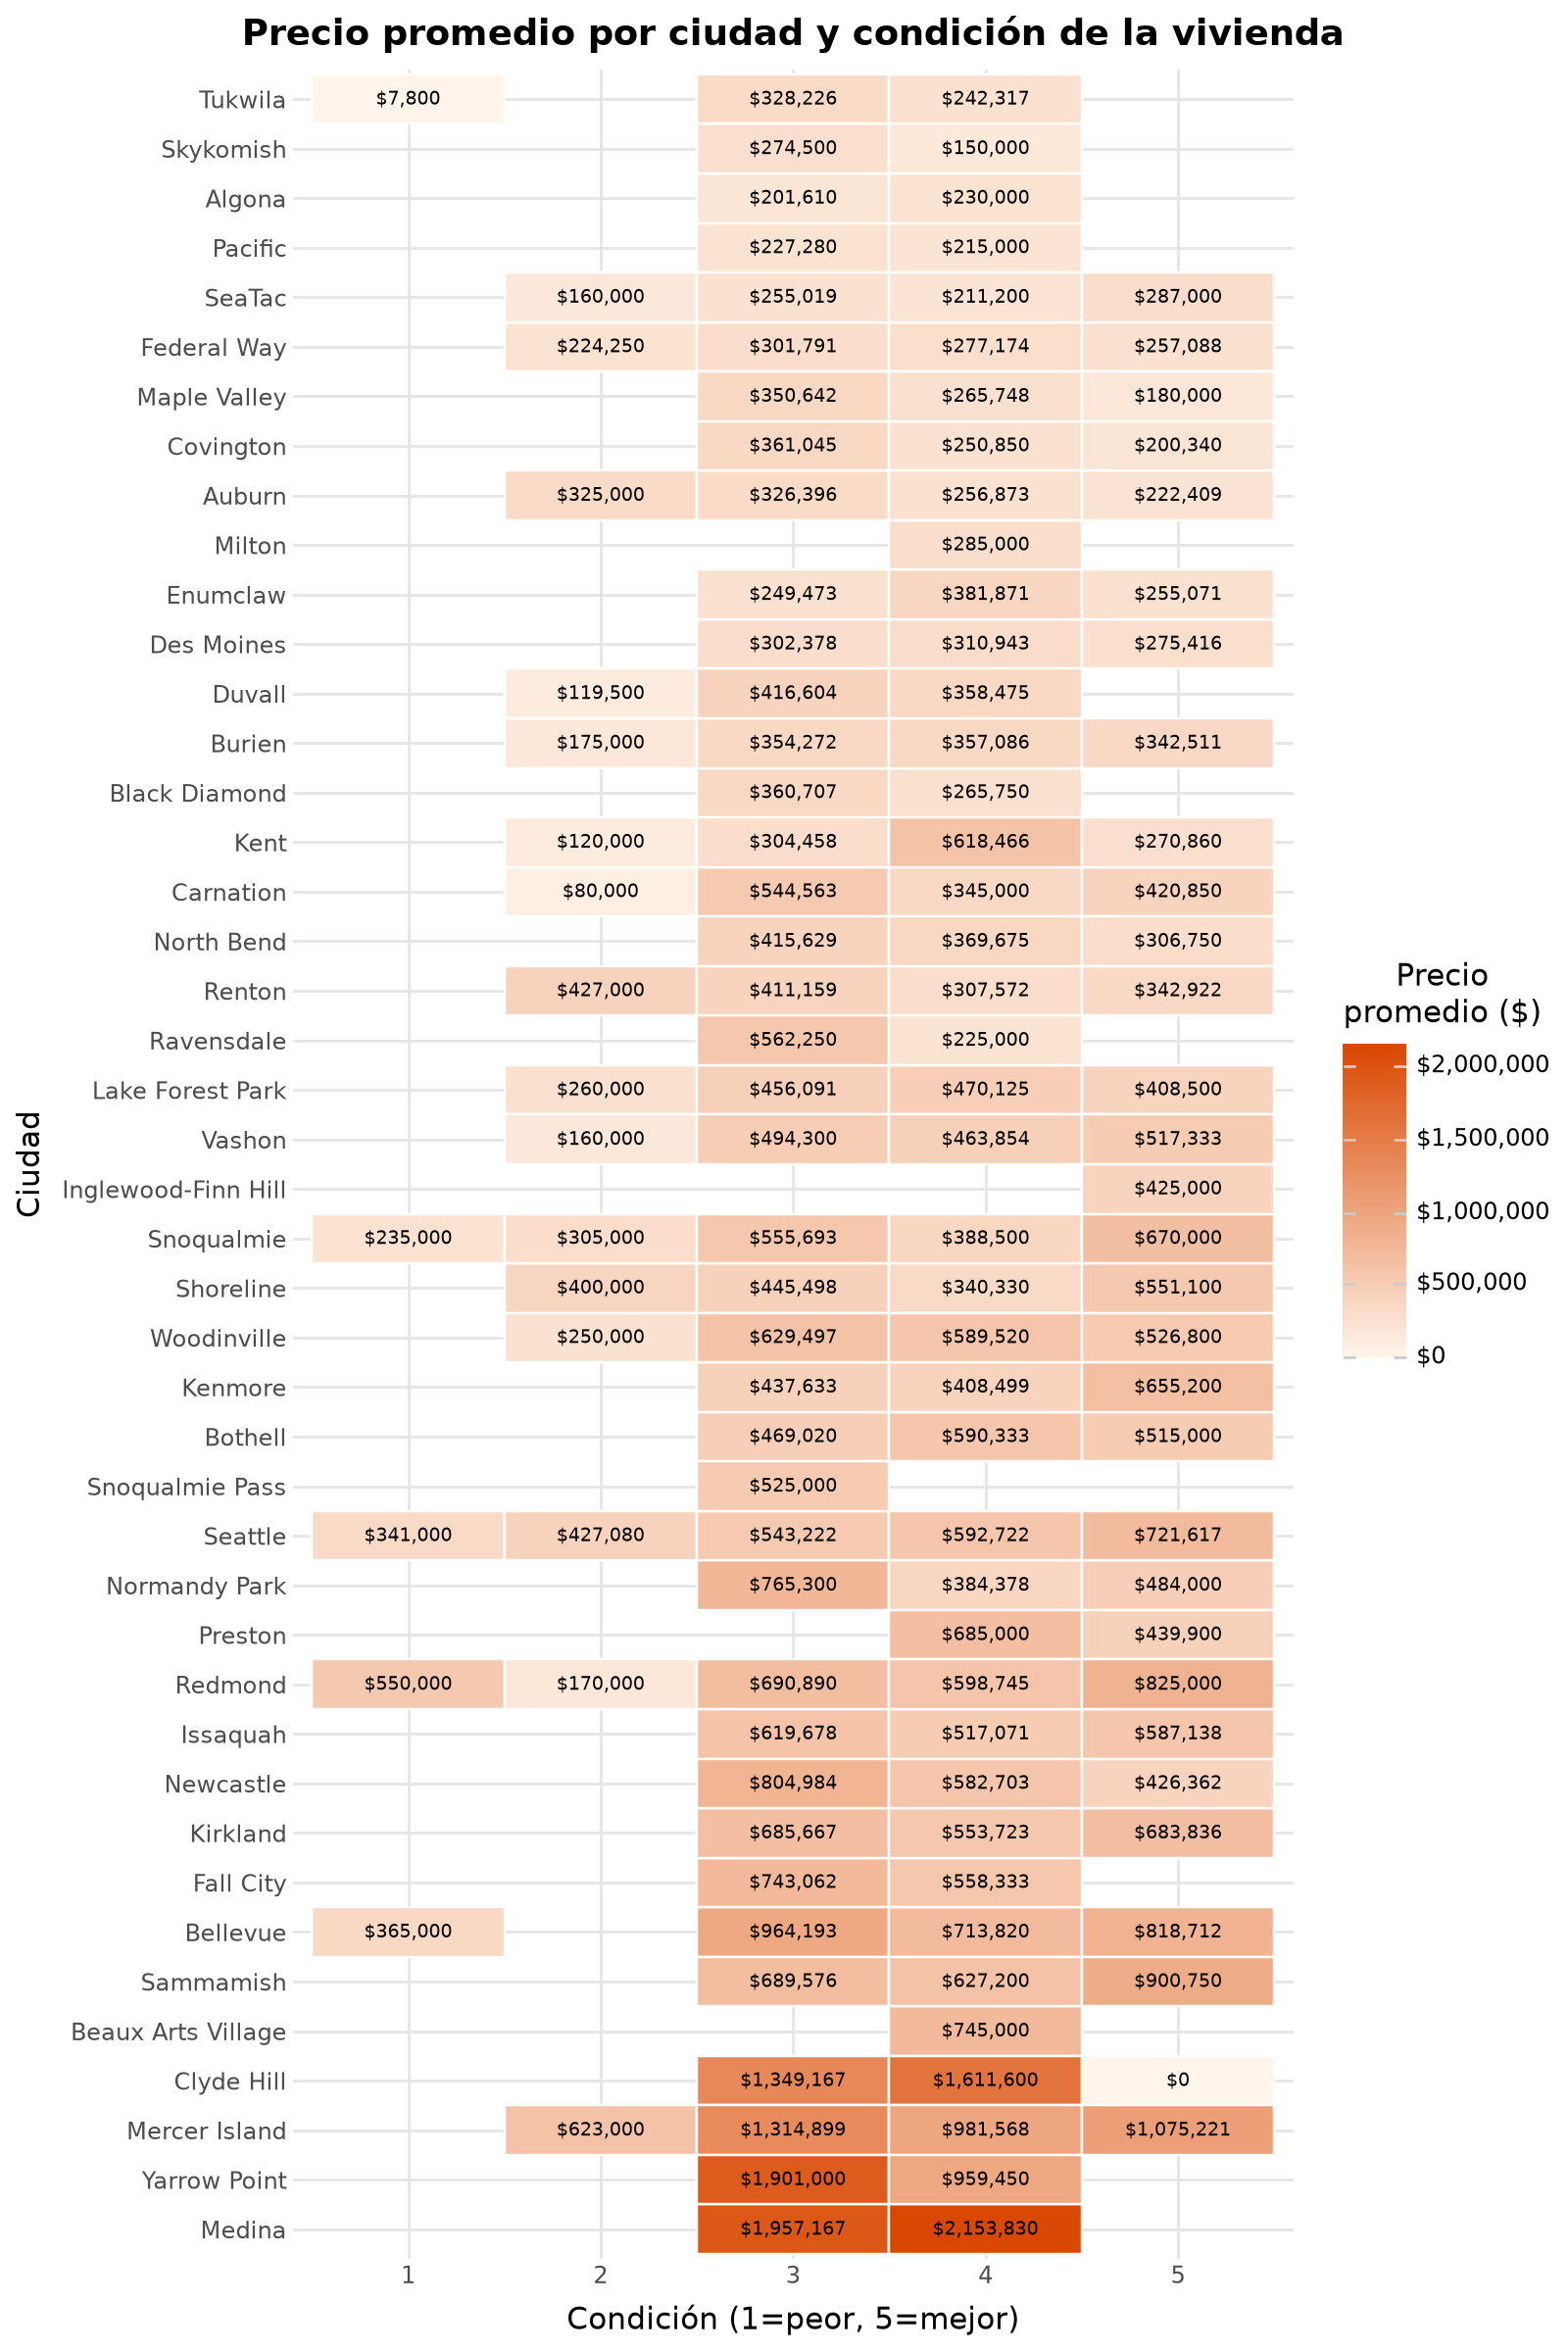

In [ ]:
# precio promedio por ciudad y condicion
price_condition = (df.groupby(['city', 'condition'])['price']
                   .mean()
                   .reset_index())
ordered_cities = price_condition.groupby('city')['price'].mean().sort_values(ascending=False).index
price_condition['city'] = pd.Categorical(price_condition['city'], categories=ordered_cities, ordered=True)

print(price_condition)

chart = (
    ggplot(price_condition, aes(x='factor(condition)', y='city', fill='price'))
    + geom_tile(color='white', size=0.5)
    + geom_text(aes(label='price.round(0).astype(int)'), size=7, color='black', format_string='${:,}')
    + scale_fill_gradient(
        low='#fff5eb', 
        high='#d94801', 
        name='Precio\npromedio ($)',
        labels=lambda l: [f'${int(v):,}' for v in l]
    )
    + labs(
        title='Precio promedio por ciudad y condición de la vivienda',
        x='Condición (1=peor, 5=mejor)',
        y='Ciudad'
    )
    + theme_minimal()
    + theme(figure_size=(8, 12), plot_title=element_text(weight='bold'))
)

chart.show()

### Heatmap de precio promedio por cuartos y baños

**Descripción del gráfico:** El heatmap muestra la relación entre el número de cuartos (*bedrooms*) y baños (*bathrooms*) en una vivienda y su precio (*price*) promedio. Cada celda representa un conjunto específico de cuartos y baños, y contiene el precio (*price*) promedio de las viviendas y el gradiente del color correspondiente a dicho promedio.

**Hallazgos principales:**
- Se observa que a medida que aumenta el número de cuartos y baños, el precio promedio también tiende a aumentar. Aunque hay algunas excepciones, como la vivienda con 0 cuartos y 0 baños, que tiene un precio promedio de $1,195,324, lo cual es un valor atípico.
- El numero de habitaciones parece ser mas influyente en el precio que el numero de baños, ya que parece haber un aumento más consistente en el precio promedio a medida que aumenta el número de cuartos, mientras que el número de baños muestra una relación menos clara con el precio.

,bedrooms,bathrooms,price
0,0.0,0.00,1.195324e+06
1,1.0,0.75,2.715688e+05
2,1.0,1.00,2.551239e+05
3,1.0,1.25,5.165000e+05
4,1.0,1.50,3.100000e+05
...,...,...,...
97,7.0,5.75,5.400000e+05
98,7.0,8.00,2.280000e+06
99,8.0,2.75,3.400000e+05
100,8.0,3.50,1.970000e+06


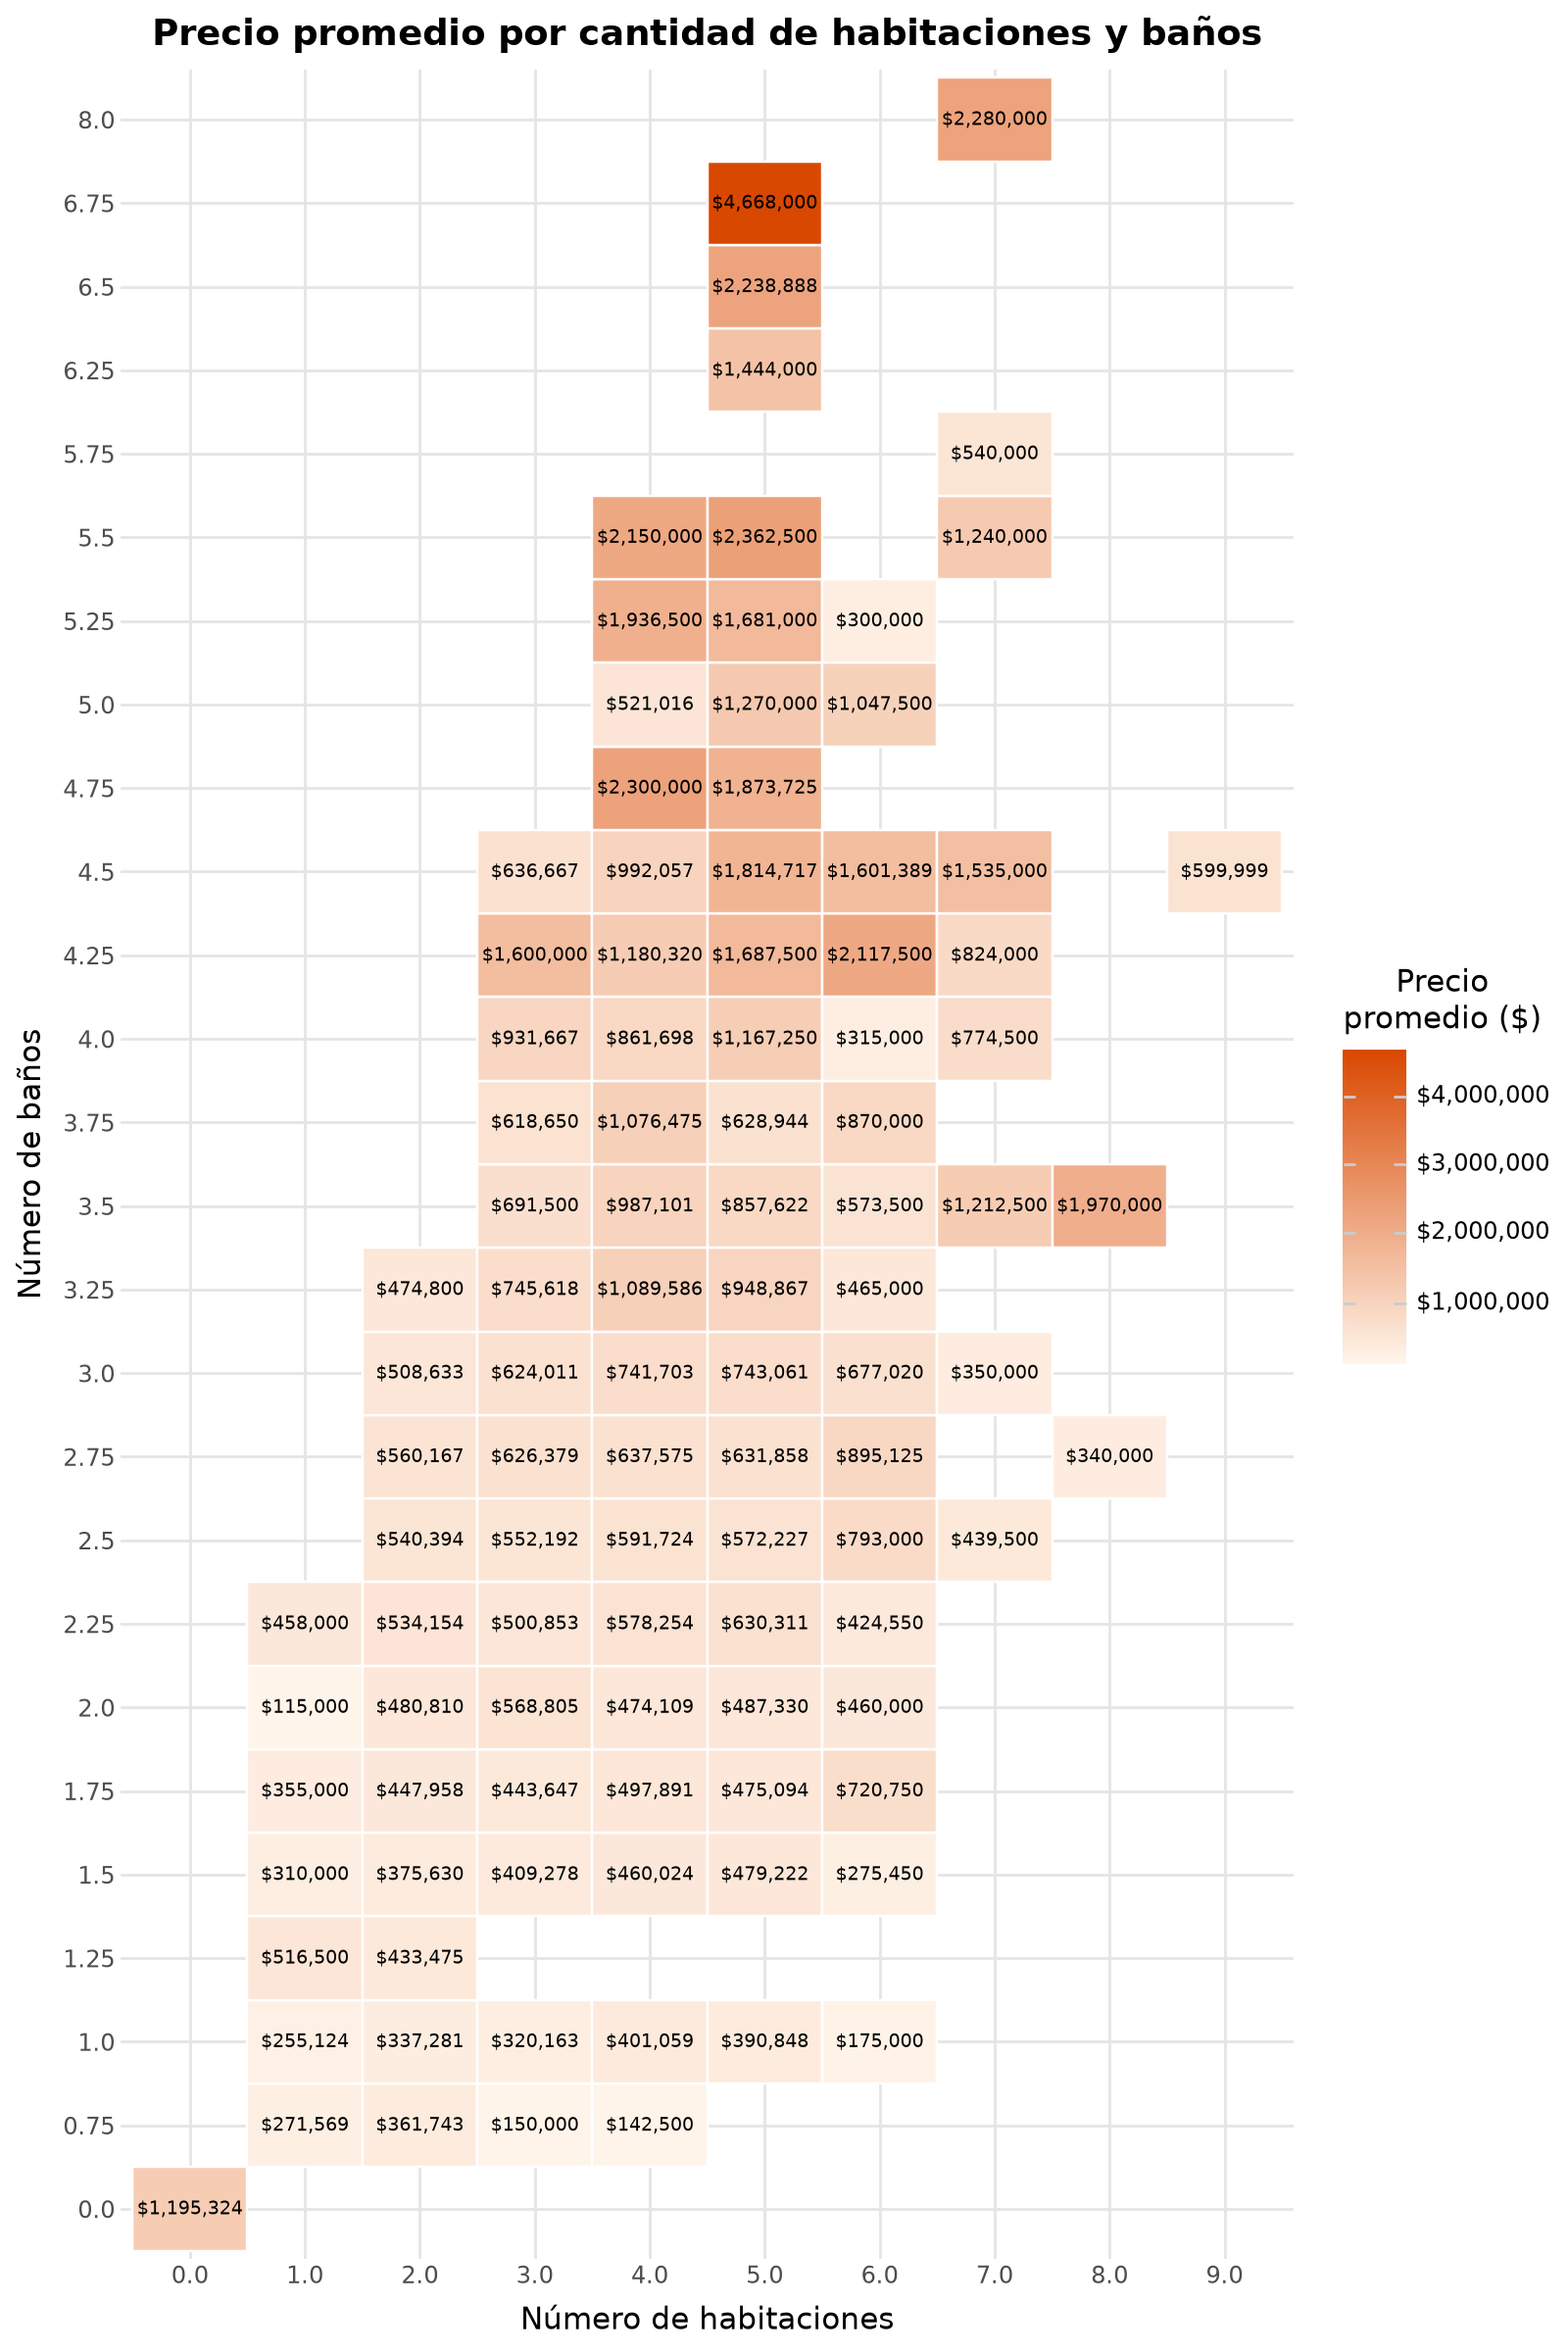

In [77]:
# heatmap de precio promedio por bedrooms y bathrooms

price_bed_bath = (df.groupby(['bedrooms', 'bathrooms'])['price']
                  .mean()
                  .reset_index())

display(price_bed_bath)

chart = (
    ggplot(price_bed_bath, aes(x='factor(bedrooms)', y='factor(bathrooms)', fill='price'))
    + geom_tile(color='white', size=0.5)
    + geom_text(aes(label='price.round(0).astype(int)'), size=7, color='black', format_string='${:,}')
    + scale_fill_gradient(
        low='#fff5eb', 
        high='#d94801', 
        name='Precio\npromedio ($)',
        labels=lambda l: [f'${int(v):,}' for v in l],
        limits=(price_bed_bath['price'].min(), price_bed_bath['price'].max())
    )
    + labs(
        title='Precio promedio por cantidad de habitaciones y baños',
        x='Número de habitaciones',
        y='Número de baños'
    )
    + theme_minimal()
    + theme(figure_size=(8, 12), plot_title=element_text(weight='bold'))
)

chart.show()

---

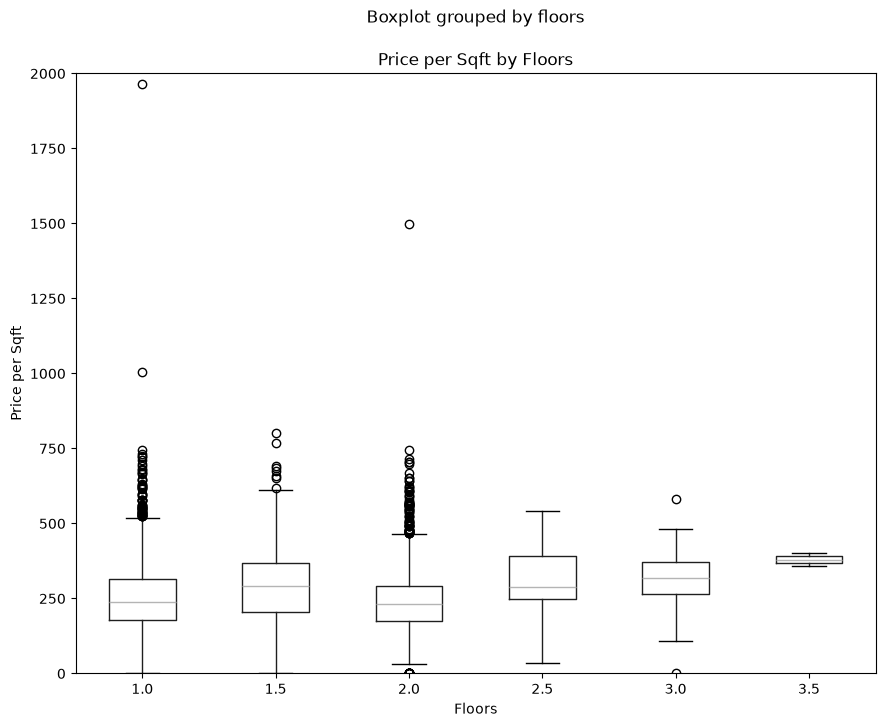

In [78]:
#boxplot of price per sqft by number of floors
df.boxplot(column='price_per_sqft', by='floors', grid=False, figsize=(10, 8))
plt.title('Price per Sqft by Floors')
plt.xlabel('Floors')
plt.ylim(0, 2000)
plt.ylabel('Price per Sqft')
plt.show()

### Boxplot Price per sqft por Número de Floors

**Descripción del gráfico:**
Para este gráfico se agrupó price_per_sqft en base al número de pisos de una vivienda. Se acotó el rango de price_per_sqft debido a valores atípicos extremos (superando valores de hasta 20000) que dificultaban la visualización de los datos.
**Hallazgos principales:**
- La mediana del precio por metro cuadrado muestra un ligero aumento mientras una vivienda poseyera más pisos.
- La mayoría de valores atípicos se concentran en las casas de 1 y 1.5 pisos, probablemente relacionado a otros factores como la zona en la que se encuentra.
- la caja de 3.5 pisos es la más compacta de todas, además de no contar con valores atípicos. Probablemente esto se deba a que hay pocos datos de viviendas en esta categoría.

**Conclusión:**
Se observa el aumento de la mediana en relación a la cantidad de pisos de la viviendas, lo cual podría sugerir que el precio por metro cuadrado si podría verse influenciado según la cantidad de pisos. Aún así, hay que tratar con cuidado esta información debido a los pocos datos dentro de las categorias de 3 y 3.5 pisos.

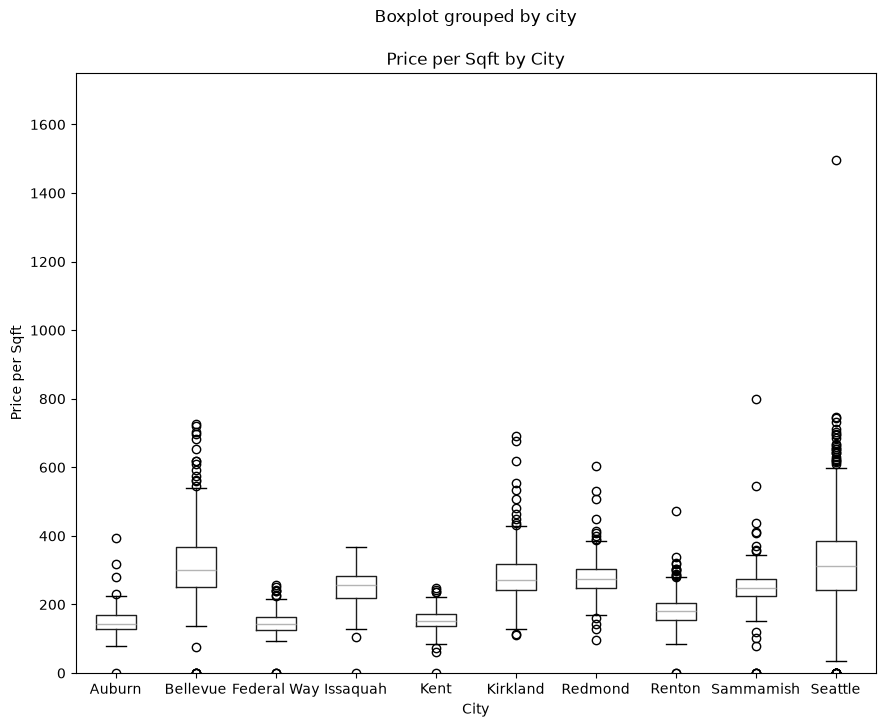

In [79]:
# boxplot of price per sqft by top 10 cities
cities = df['city'].value_counts().head(10).index
df_top = df[df['city'].isin(cities)]
df_top.boxplot(column='price_per_sqft', by='city', grid=False, figsize=(10, 8))
plt.title('Price per Sqft by City')
plt.xlabel('City')
plt.ylim(0, 1750)
plt.ylabel('Price per Sqft')
plt.show()


### Boxplot Price per sqft por City

**Descripción del gráfico:**
Para este gráfico, se agrupó el price_per_sqft en base al top 10 ciudades del dataset (city), para de esta manera comparar la distribución del precio por metro cuadrado de la vivienda según su ubicación. El rango de valores de price_per_sqft fue acotado debido a valores extremos (superiores a 5000 y a 20000) que distorsionaban la escala del gráfico y dificultaba la visualización del mismo.

**Hallazgos principales:**
- Se puede observar que los hogares mejor valorados por metro cuadrado están entre las ciudades de Seattle y Bellevue y Sammamish.
- Seattle y Bellevue son las ciudades que poseen más dispersión y valores atipicos. Esto podría deberse a la variabilidad de los precios segun la zona de dichas ciudades.
- Las ciudades más pequeñas como Kent o Auburn muestran cajas más compactas y consistentes.

**Conclusión:**
Con este boxplot podríamos considerar que la ubicación (city) es un factor relevante en la diferencia de precios por metro cuadrado de las viviendas, por lo que debería considerarse para análisis basados en el precio de viviendas.

## Grafico de linea de precio promedio por pie cuadrado por año de construcción

Este tipo de gráfico fue tomado de [d3js.org](d3js.org)

**Descripcion del gráfico:** Este gráfico de líneas muestra el precio promedio por pie cuadrado de las viviendas en cada año en que fueron construidas. Cada punto en la línea representa el precio promedio de las viviendas en ese año específico.

**Hallazgos importantes:**
- Se nota una tendencia general de disminución del precio promedio por pie cuadrado a medida que las viviendas son más nuevas, con 1 outlier, llevando a pensar que las viviendas mas antiguas se encuentran en mejores ubicaciones o son de mejor calidad, por el mayor precio.

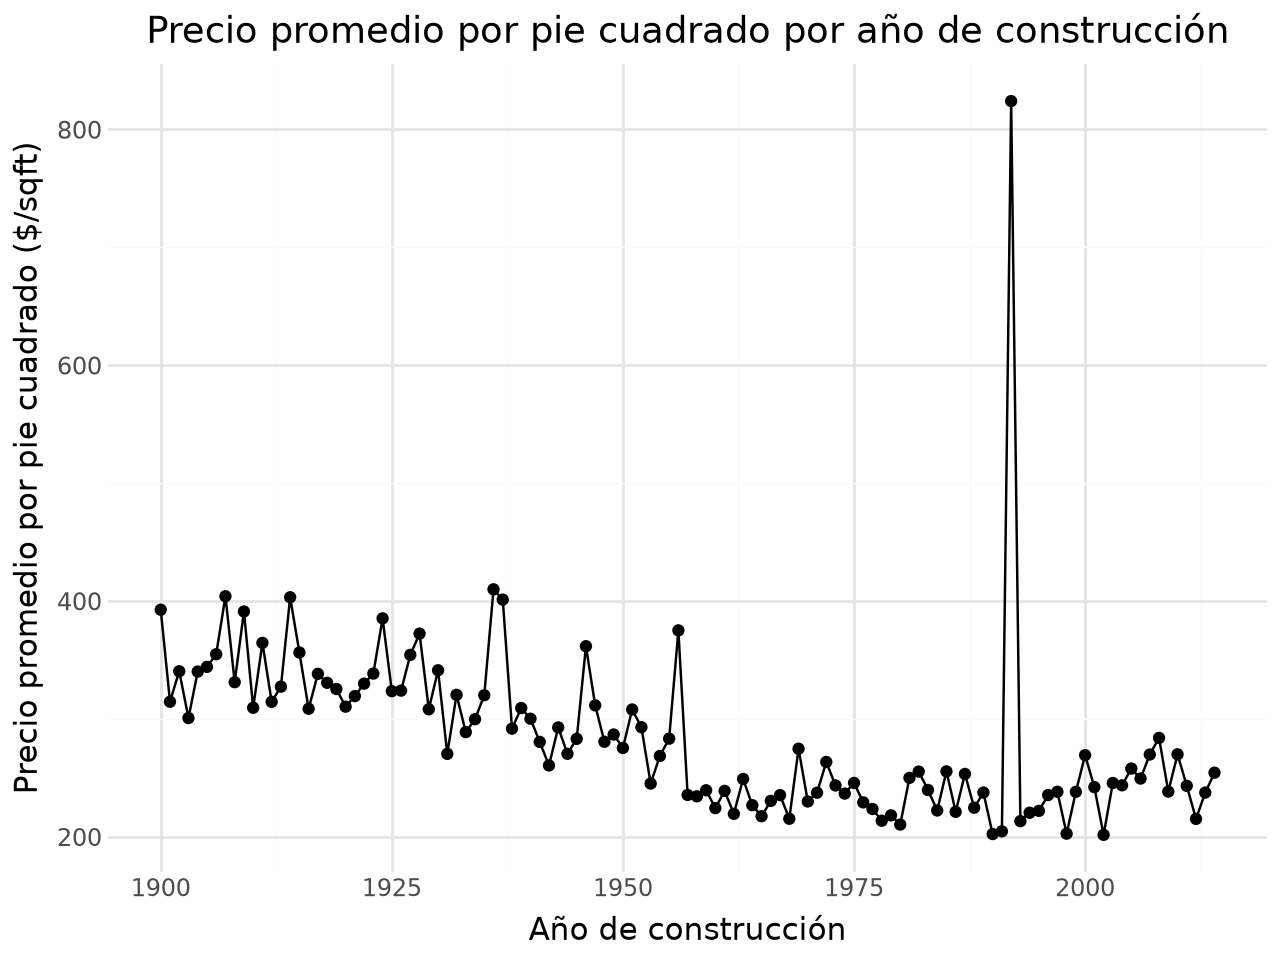

In [138]:
price_year = (df.groupby('yr_built')['price_per_sqft']
              .mean()
              .reset_index())

(
    ggplot(price_year, aes(x='yr_built', y='price_per_sqft')) 
    + geom_line() 
    + geom_point() 
    + labs(
        title='Precio promedio por pie cuadrado por año de construcción',
        x='Año de construcción',
        y='Precio promedio por pie cuadrado ($/sqft)') 
    + theme_minimal()
)